# 🔍 Détection d'Anomalies — Portefeuille Assurance

Ce notebook détecte les comportements anormaux dans le portefeuille d'assurance à l'aide de plusieurs algorithmes non-supervisés :

| Algorithme | Usage principal |
|---|---|
| **Isolation Forest** | Anomalies globales dans les primes / sinistres |
| **LOF (Local Outlier Factor)** | Anomalies locales densité-basées |
| **Autoencoder** | Reconstruction d'erreur sur les quittances |
| **DBSCAN** | Clustering pour détecter les outliers |
| **Z-Score / IQR** | Anomalies univariées rapides |

**Sources de données :** `DWH_FACT_EMISSION`, `DWH_FACT_SINISTRE`, `DWH_FACT_IMPAYE`, `DWH_FACT_ANNULATION`, `DIM_POLICE`, `DIM_CLIENT`


## 1. Imports & Configuration

In [65]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from scipy import stats

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Display
from IPython.display import display
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Style
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']
sns.set_palette(PALETTE)

print(f"TensorFlow  : {tf.__version__}")
print(f"Pandas      : {pd.__version__}")
print("✅ Imports OK")


TensorFlow  : 2.15.0
Pandas      : 2.3.3
✅ Imports OK


## 2. Chargement des Données

In [66]:
DATA_PATH = Path("C:/Users/LENOVO/Desktop/PFE_/maghrebia/data/raw")      

def load(name):
    return pd.read_csv(DATA_PATH / f"{name}.csv", low_memory=False)

emission   = load("DWH_FACT_EMISSION")
sinistre   = load("DWH_FACT_SINISTRE")
impaye     = load("DWH_FACT_IMPAYE")
annulation = load("DWH_FACT_ANNULATION")
police     = load("DIM_POLICE")
client     = load("DIM_CLIENT")
dim_agent  = load("DIM_AGENT")

print("Dimensions :")
for name, df in [("EMISSION", emission), ("SINISTRE", sinistre),
                 ("IMPAYE", impaye), ("ANNULATION", annulation),
                 ("POLICE", police), ("CLIENT", client)]:
    print(f"  {name:<12} : {df.shape[0]:>7,} lignes  ×  {df.shape[1]} colonnes")


Dimensions :
  EMISSION     :  65,000 lignes  ×  33 colonnes
  SINISTRE     :   8,000 lignes  ×  16 colonnes
  IMPAYE       :     868 lignes  ×  16 colonnes
  ANNULATION   :   1,273 lignes  ×  22 colonnes
  POLICE       :  30,000 lignes  ×  16 colonnes
  CLIENT       :  30,000 lignes  ×  13 colonnes


## 3. Feature Engineering & Préprocessing

In [67]:
# ── 3.1  Nettoyage Emission ──────────────────────────────────────────────
date_cols_em = ['DATE_EFFET', 'DATE_ECHEANCE', 'DATE_EMISSION']
for c in date_cols_em:
    emission[c] = pd.to_datetime(emission[c], errors='coerce')

emission['DELAI_EMISSION_JOURS'] = (
    emission['DATE_EMISSION'] - emission['DATE_EFFET']
).dt.days

# Montant total prime nette
mt_cols = [c for c in emission.columns if c.startswith('MT_')]
emission['MT_TOTAL'] = emission[mt_cols].fillna(0).sum(axis=1)
emission['MT_PNET']  = emission['MT_PNET'].fillna(0)

# Ratio commission / prime
emission['RATIO_COMMISSION'] = (
    emission['MT_COMMISSION'].fillna(0) /
    emission['MT_PNET'].replace(0, np.nan)
)

# Encode etat quittance
etat_map = {'P': 0, 'p': 0, 'E': 1, 'e': 1, 'A': 2, 'X': 3}
emission['ETAT_CODE'] = emission['ETAT_QUIT'].map(etat_map).fillna(-1)

print("Emission — nouvelles features :")
print(emission[['MT_TOTAL', 'MT_PNET', 'RATIO_COMMISSION',
                'DELAI_EMISSION_JOURS', 'ETAT_CODE']].describe())


Emission — nouvelles features :
         MT_TOTAL     MT_PNET  RATIO_COMMISSION  DELAI_EMISSION_JOURS  \
count    65000.00    65000.00          61612.00              61766.00   
mean     11738.66     4416.51              0.14                -14.94   
std     117730.04    78598.40              0.05                  8.94   
min          0.20   -56841.53             -0.24                -30.00   
25%        596.21      163.16              0.11                -23.00   
50%       1292.86      354.37              0.15                -15.00   
75%       2745.42      739.44              0.18                 -7.00   
max   14675374.89 11309863.86              0.34                  0.00   

       ETAT_CODE  
count   65000.00  
mean        0.46  
std         0.76  
min        -1.00  
25%         0.00  
50%         0.00  
75%         1.00  
max         3.00  


In [68]:
# ── 3.2  Agrégation par police (vue contrat) ─────────────────────────────
police_agg = emission.groupby('ID_POLICE').agg(
    NB_QUITTANCES   = ('NUM_QUITTANCE', 'count'),
    MT_PNET_TOTAL   = ('MT_PNET', 'sum'),
    MT_PNET_MOY     = ('MT_PNET', 'mean'),
    MT_PNET_STD     = ('MT_PNET', 'std'),
    MT_COMMISSION   = ('MT_COMMISSION', 'sum'),
    RATIO_COM_MOY   = ('RATIO_COMMISSION', 'mean'),
    NB_ANNULE       = ('ETAT_CODE', lambda x: (x == 2).sum()),
    NB_EN_COURS     = ('ETAT_CODE', lambda x: (x == 1).sum()),
    DELAI_MOY       = ('DELAI_EMISSION_JOURS', 'mean'),
    BONUS_MALUS_MOY = ('BONUS_MALUS', 'mean'),
).reset_index()

# Ajout des impayés
impaye_agg = impaye.groupby('ID_POLICE').agg(
    NB_IMPAYE     = ('NUM_QUITTANCE', 'count'),
    MT_IMPAYE_TOT = ('MT_PNN', 'sum'),
).reset_index()

# Ajout des sinistres
sinistre_agg = sinistre.groupby('ID_POLICE').agg(
    NB_SINISTRES   = ('NUM_SINISTRE', 'count'),
    MT_EVAL_TOT    = ('MT_EVALUATION', 'sum'),
    MT_PAYE_TOT    = ('MT_PAYE', 'sum'),
).reset_index()

# Merge
df_police = police_agg     .merge(impaye_agg,   on='ID_POLICE', how='left')     .merge(sinistre_agg, on='ID_POLICE', how='left')     .merge(police[['ID_POLICE', 'BRANCHE', 'BONUS_MALUS', 'SITUATION']],
           on='ID_POLICE', how='left')

df_police[['NB_IMPAYE', 'MT_IMPAYE_TOT',
           'NB_SINISTRES', 'MT_EVAL_TOT', 'MT_PAYE_TOT']] =     df_police[['NB_IMPAYE', 'MT_IMPAYE_TOT',
               'NB_SINISTRES', 'MT_EVAL_TOT', 'MT_PAYE_TOT']].fillna(0)

# Ratios dérivés
df_police['TAUX_IMPAYE']    = df_police['NB_IMPAYE']    / df_police['NB_QUITTANCES'].replace(0,1)
df_police['TAUX_ANNULE']    = df_police['NB_ANNULE']    / df_police['NB_QUITTANCES'].replace(0,1)
df_police['LOSS_RATIO']     = df_police['MT_PAYE_TOT']  / df_police['MT_PNET_TOTAL'].replace(0,np.nan)
df_police['FREQ_SINISTRE']  = df_police['NB_SINISTRES'] / df_police['NB_QUITTANCES'].replace(0,1)

df_police.fillna(0, inplace=True)
print(f"Dataset contrats  : {df_police.shape}")
df_police.head(3)


Dataset contrats  : (23900, 23)


,ID_POLICE,NB_QUITTANCES,MT_PNET_TOTAL,MT_PNET_MOY,MT_PNET_STD,MT_COMMISSION,RATIO_COM_MOY,NB_ANNULE,NB_EN_COURS,DELAI_MOY,BONUS_MALUS_MOY,NB_IMPAYE,MT_IMPAYE_TOT,NB_SINISTRES,MT_EVAL_TOT,MT_PAYE_TOT,BRANCHE,BONUS_MALUS,SITUATION,TAUX_IMPAYE,TAUX_ANNULE,LOSS_RATIO,FREQ_SINISTRE
0,1,2,490.89,245.45,105.50,61.31,0.12,0,0,-6.50,8.00,0.00,0.00,1.00,5865.97,4499.00,AUTO,8.00,V,0.00,0.00,9.16,0.50
1,3,1,477.09,477.09,0.00,94.13,0.20,0,0,-29.00,4.00,0.00,0.00,0.00,0.00,0.00,AUTO,4.00,V,0.00,0.00,0.00,0.00
2,4,5,3218.24,643.65,200.44,480.38,0.14,0,0,-10.50,5.00,0.00,0.00,1.00,566.74,0.00,AUTO,5.00,V,0.00,0.00,0.00,0.20


## 4. Sélection des Features & Normalisation

In [69]:
FEATURES = [
    'NB_QUITTANCES', 'MT_PNET_TOTAL', 'MT_PNET_MOY', 'MT_PNET_STD',
    'RATIO_COM_MOY', 'TAUX_IMPAYE', 'TAUX_ANNULE', 'LOSS_RATIO',
    'FREQ_SINISTRE', 'MT_IMPAYE_TOT', 'MT_EVAL_TOT', 'DELAI_MOY',
    'BONUS_MALUS_MOY',
]

X = df_police[FEATURES].copy()
X.replace([np.inf, -np.inf], 0, inplace=True)
X.fillna(0, inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)

print(f"Shape features : {X_scaled.shape}")
print("\nStatistiques (normalisé) :")
pd.DataFrame(X_scaled, columns=FEATURES).describe().round(2)


Shape features : (23900, 13)

Statistiques (normalisé) :


,NB_QUITTANCES,MT_PNET_TOTAL,MT_PNET_MOY,MT_PNET_STD,RATIO_COM_MOY,TAUX_IMPAYE,TAUX_ANNULE,LOSS_RATIO,FREQ_SINISTRE,MT_IMPAYE_TOT,MT_EVAL_TOT,DELAI_MOY,BONUS_MALUS_MOY
count,23900.00,23900.00,23900.00,23900.00,23900.00,23900.00,23900.00,23900.00,23900.00,23900.00,23900.00,23900.00,23900.00
mean,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.18,-0.52,-1.25,-0.04,-8.02,-0.16,-0.59,-15.13,-0.41,-3.23,-0.15,-2.30,-1.11
25%,-0.50,-0.09,-0.09,-0.04,-0.55,-0.16,-0.59,-0.07,-0.41,-0.02,-0.15,-0.64,-1.11
50%,-0.50,-0.08,-0.08,-0.04,0.15,-0.16,-0.59,-0.07,-0.41,-0.02,-0.15,-0.04,-0.06
75%,0.88,-0.07,-0.08,-0.04,0.69,-0.16,0.42,-0.07,-0.41,-0.02,-0.15,0.64,0.65
max,6.39,85.74,99.16,89.11,3.74,12.43,3.44,84.19,15.12,148.33,68.01,2.23,2.41


## 5. Réduction Dimensionnelle (PCA)

Variance expliquée — PC1: 22.8%  PC2: 12.8%


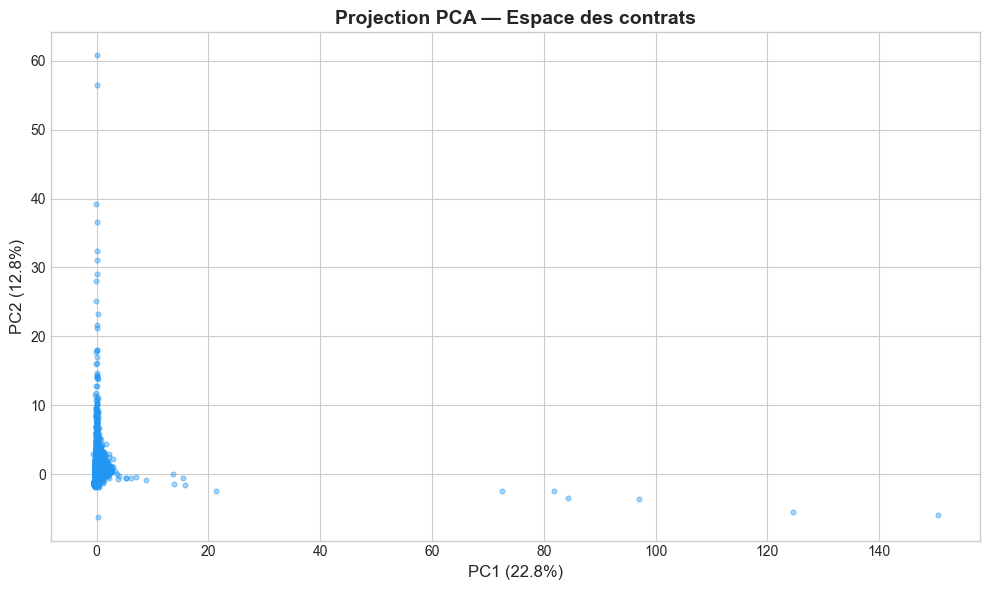

In [70]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée — PC1: {pca.explained_variance_ratio_[0]:.1%}  "
      f"PC2: {pca.explained_variance_ratio_[1]:.1%}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=12, color=PALETTE[0])
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax.set_title('Projection PCA — Espace des contrats', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Isolation Forest

In [71]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # 5% d'anomalies supposées
    max_samples='auto',
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_scaled)

df_police['IF_SCORE']  = iso.score_samples(X_scaled)   # plus négatif = plus anormal
df_police['IF_LABEL']  = iso.predict(X_scaled)          # -1 = anomalie, 1 = normal
df_police['IF_ANOMALY'] = (df_police['IF_LABEL'] == -1).astype(int)

n_anom = df_police['IF_ANOMALY'].sum()
print(f"Isolation Forest → {n_anom} anomalies détectées ({n_anom/len(df_police):.1%})")
print()
print("Distribution des anomalies par branche :")
display(df_police.groupby('BRANCHE')['IF_ANOMALY'].agg(['sum', 'mean'])
        .rename(columns={'sum': 'Nb_anomalies', 'mean': 'Taux'})
        .sort_values('Nb_anomalies', ascending=False))


Isolation Forest → 1195 anomalies détectées (5.0%)

Distribution des anomalies par branche :


,Nb_anomalies,Taux
BRANCHE,,
SANTE,702,0.44
AUTO,290,0.02
IRDS,203,0.03


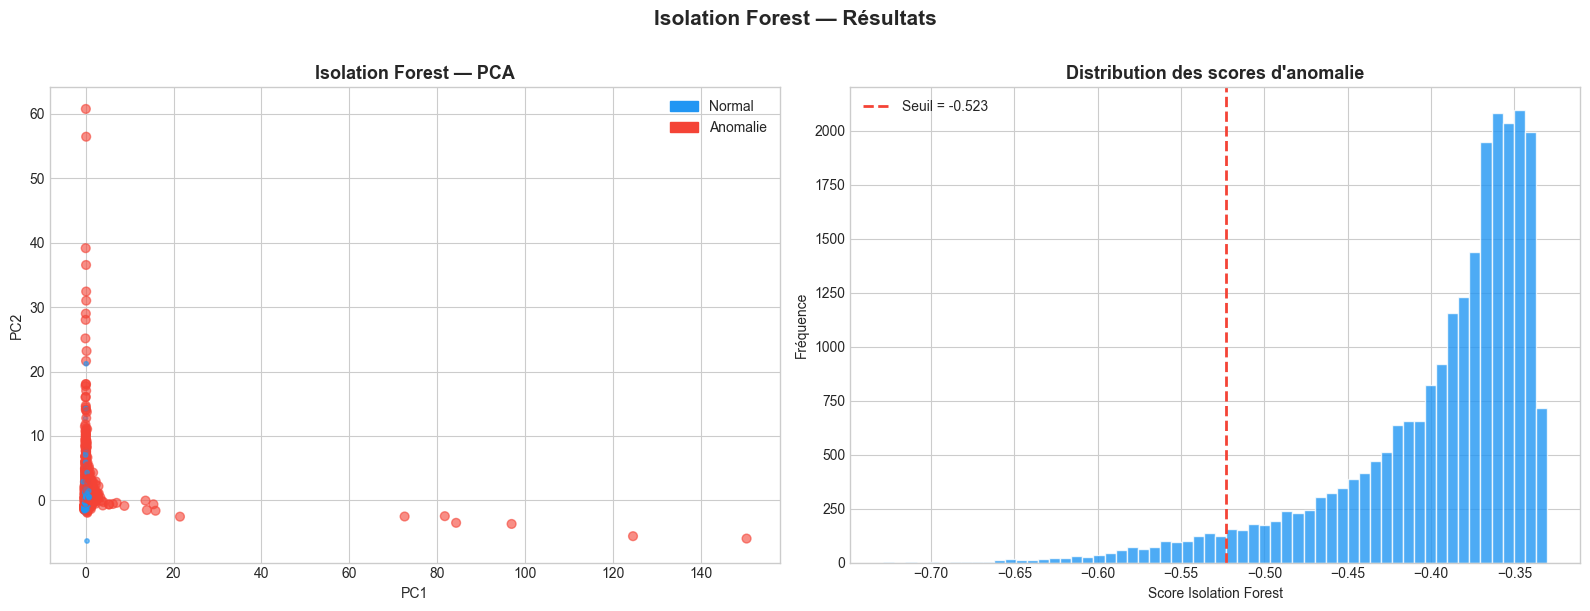

In [72]:
# Visualisation PCA colorée par IF
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = df_police['IF_ANOMALY'].map({0: PALETTE[0], 1: PALETTE[1]})
sizes  = df_police['IF_ANOMALY'].map({0: 10, 1: 40})

ax = axes[0]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=sizes, alpha=0.6)
normal_p  = mpatches.Patch(color=PALETTE[0], label='Normal')
anomaly_p = mpatches.Patch(color=PALETTE[1], label='Anomalie')
ax.legend(handles=[normal_p, anomaly_p])
ax.set_title('Isolation Forest — PCA', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

ax = axes[1]
ax.hist(df_police['IF_SCORE'], bins=60, color=PALETTE[0], edgecolor='white', alpha=0.8)
thresh = df_police.loc[df_police['IF_ANOMALY']==1, 'IF_SCORE'].max()
ax.axvline(thresh, color=PALETTE[1], linestyle='--', linewidth=2, label=f'Seuil = {thresh:.3f}')
ax.set_title("Distribution des scores d'anomalie", fontsize=13, fontweight='bold')
ax.set_xlabel('Score Isolation Forest'); ax.set_ylabel('Fréquence')
ax.legend()

plt.suptitle('Isolation Forest — Résultats', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Local Outlier Factor (LOF)

LOF → 1195 anomalies détectées (5.0%)
Anomalies confirmées par IF ET LOF : 252


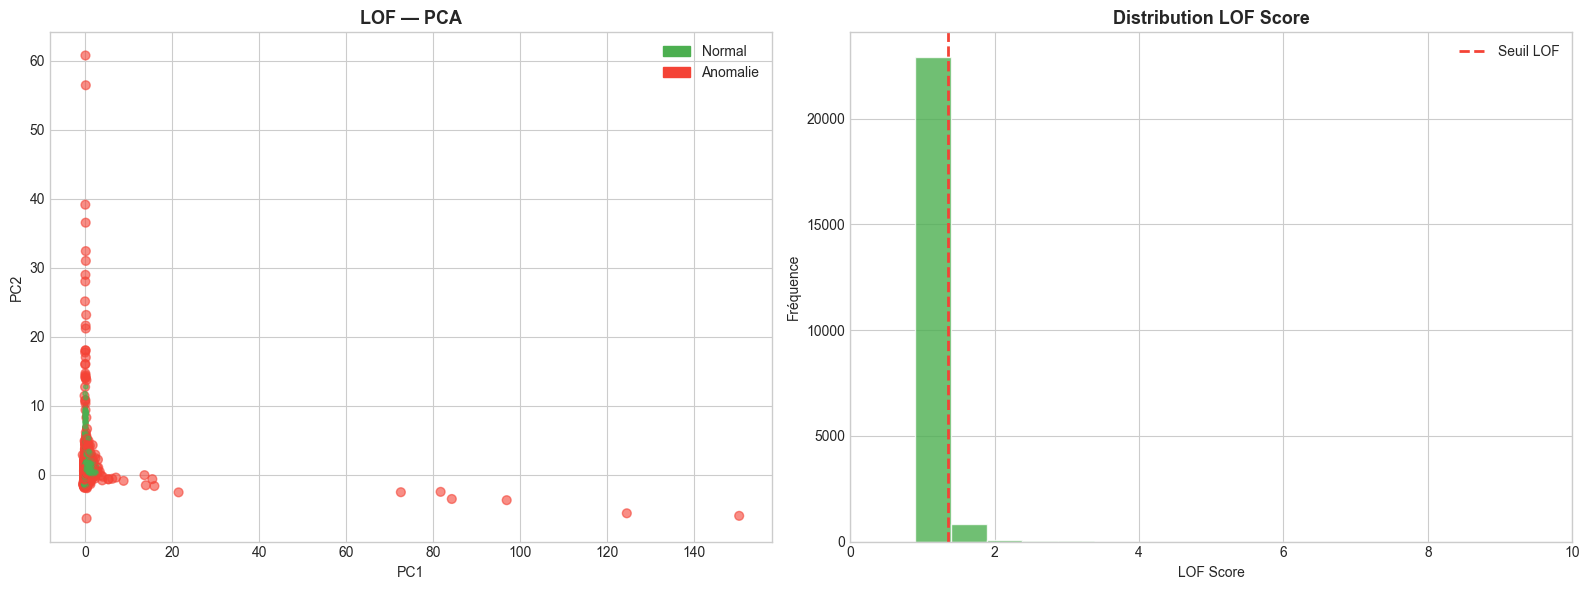

In [73]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    metric='euclidean',
    n_jobs=-1,
)
lof_pred = lof.fit_predict(X_scaled)

df_police['LOF_SCORE']  = -lof.negative_outlier_factor_
df_police['LOF_LABEL']  = lof_pred
df_police['LOF_ANOMALY'] = (lof_pred == -1).astype(int)

n_lof = df_police['LOF_ANOMALY'].sum()
print(f"LOF → {n_lof} anomalies détectées ({n_lof/len(df_police):.1%})")

# Accord entre IF et LOF
df_police['BOTH_ANOMALY'] = ((df_police['IF_ANOMALY'] == 1) &
                              (df_police['LOF_ANOMALY'] == 1)).astype(int)
print(f"Anomalies confirmées par IF ET LOF : {df_police['BOTH_ANOMALY'].sum()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_lof = df_police['LOF_ANOMALY'].map({0: PALETTE[2], 1: PALETTE[1]})
ax = axes[0]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_lof,
           s=df_police['LOF_ANOMALY'].map({0: 10, 1: 40}), alpha=0.6)
ax.legend(handles=[mpatches.Patch(color=PALETTE[2], label='Normal'),
                   mpatches.Patch(color=PALETTE[1], label='Anomalie')])
ax.set_title('LOF — PCA', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

ax = axes[1]
ax.hist(df_police['LOF_SCORE'], bins=60, color=PALETTE[2], edgecolor='white', alpha=0.8)
ax.axvline(df_police.loc[df_police['LOF_ANOMALY']==1,'LOF_SCORE'].min(),
           color=PALETTE[1], linestyle='--', linewidth=2, label='Seuil LOF')
ax.set_title('Distribution LOF Score', fontsize=13, fontweight='bold')
ax.set_xlabel('LOF Score'); ax.set_ylabel('Fréquence')
ax.legend()
ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()


## 8. DBSCAN — Clustering & Outliers

DBSCAN → 1 clusters  |  61 points aberrants (0.3%)


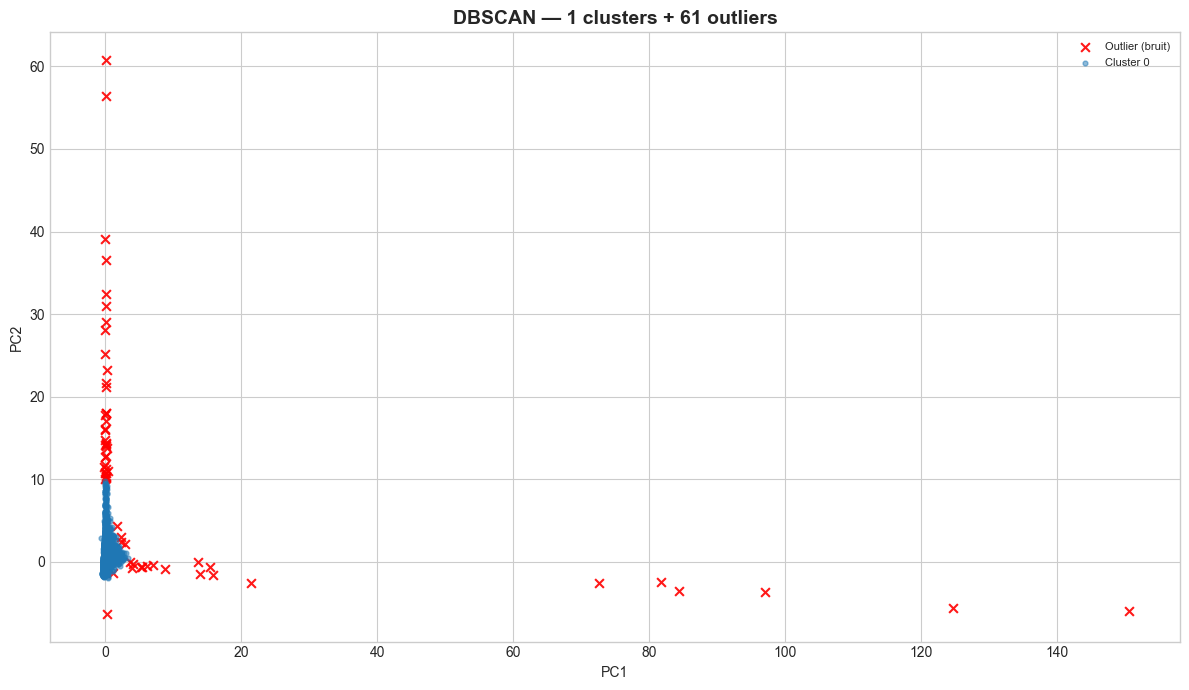

In [74]:
# DBSCAN sur les 2 premières composantes PCA pour lisibilité
dbscan = DBSCAN(eps=0.5, min_samples=10, metric='euclidean', n_jobs=-1)
db_labels = dbscan.fit_predict(X_pca)

df_police['DBSCAN_CLUSTER'] = db_labels
df_police['DBSCAN_ANOMALY'] = (db_labels == -1).astype(int)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
print(f"DBSCAN → {n_clusters} clusters  |  {n_noise} points aberrants ({n_noise/len(db_labels):.1%})")

# Visualisation
fig, ax = plt.subplots(figsize=(12, 7))
unique_labels = sorted(set(db_labels))
cmap = plt.cm.get_cmap('tab20', len(unique_labels))

for k in unique_labels:
    mask = db_labels == k
    label = f'Cluster {k}' if k >= 0 else 'Outlier (bruit)'
    color = 'red' if k == -1 else cmap(k)
    size  = 40 if k == -1 else 12
    alpha = 0.9 if k == -1 else 0.5
    marker = 'x' if k == -1 else 'o'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[color], s=size, alpha=alpha, marker=marker, label=label)

ax.set_title(f'DBSCAN — {n_clusters} clusters + {n_noise} outliers',
             fontsize=14, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
if len(unique_labels) <= 12:
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


## 9. Autoencoder (Réseau de Neurones)

In [75]:
# Architecture
input_dim = X_scaled.shape[1]
encoding_dim = 6

tf.random.set_seed(42)

inputs  = keras.Input(shape=(input_dim,))
encoded = layers.Dense(16, activation='relu')(inputs)
encoded = layers.BatchNormalization()(encoded)
encoded = layers.Dense(encoding_dim, activation='relu', name='bottleneck')(encoded)
decoded = layers.Dense(16, activation='relu')(encoded)
decoded = layers.Dense(input_dim, activation='linear', name='output')(decoded)

autoencoder = keras.Model(inputs, decoded, name='Autoencoder')
encoder     = keras.Model(inputs, autoencoder.get_layer('bottleneck').output)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "Autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 13)]              0         
                                                                 
 dense_6 (Dense)             (None, 16)                224       
                                                                 
 batch_normalization_3 (Bat  (None, 16)                64        
 chNormalization)                                                
                                                                 
 bottleneck (Dense)          (None, 6)                 102       
                                                                 
 dense_7 (Dense)             (None, 16)                112       
                                                                 
 output (Dense)              (None, 13)                221       
                                                       

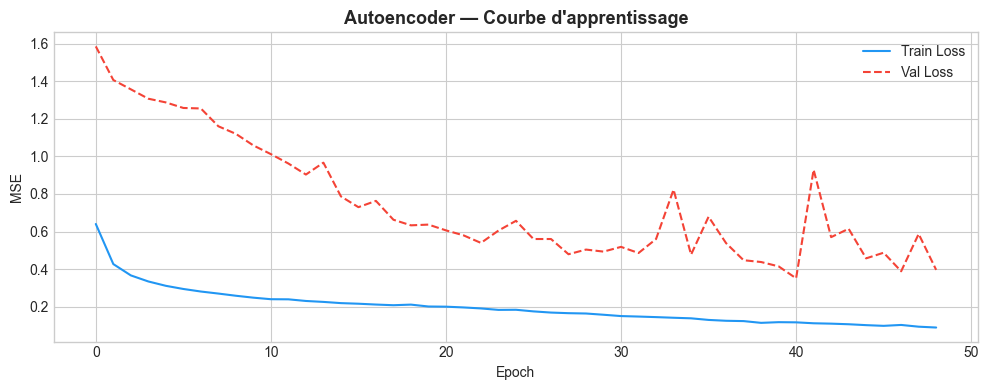

In [76]:
# Entraînement sur les données normales (ETAT=normal)
history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=60,
    batch_size=64,
    shuffle=True,
    validation_split=0.15,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)
    ]
)

# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Train Loss', color=PALETTE[0])
ax.plot(history.history['val_loss'], label='Val Loss',   color=PALETTE[1], linestyle='--')
ax.set_title("Autoencoder — Courbe d'apprentissage", fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()
plt.show()


Seuil reconstruction (p95) : 0.2639
Autoencoder → 1195 anomalies détectées


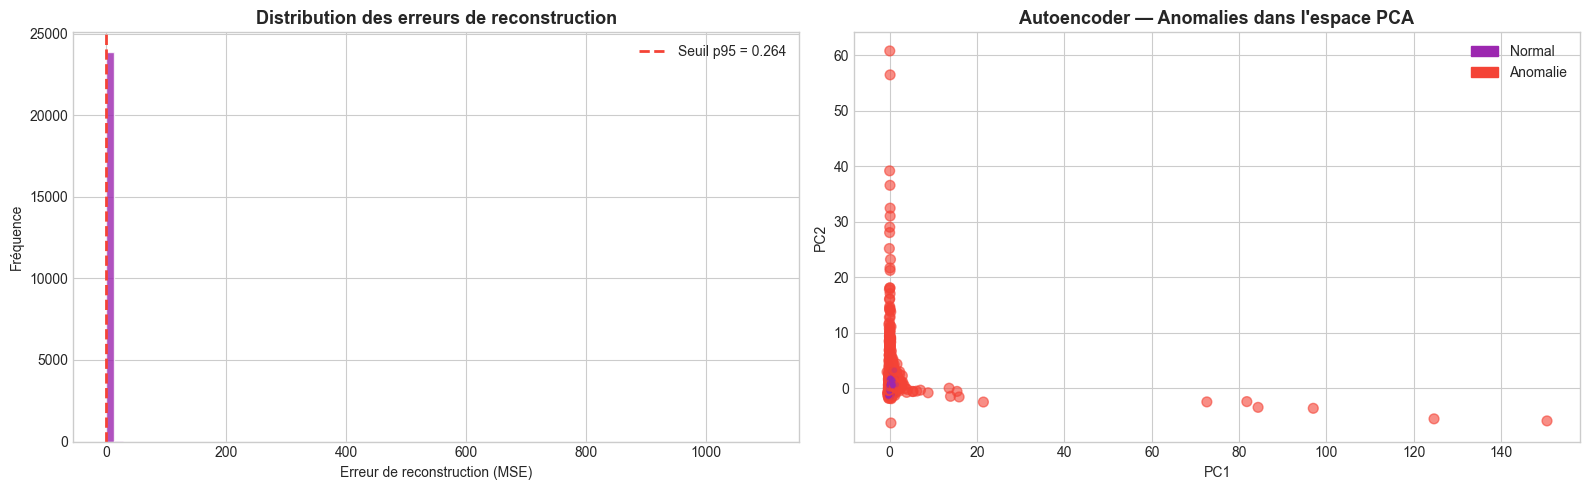

In [77]:
# Calcul des erreurs de reconstruction
X_pred = autoencoder.predict(X_scaled, verbose=0)
reconstruction_error = np.mean(np.square(X_scaled - X_pred), axis=1)

df_police['AE_RECON_ERROR'] = reconstruction_error

# Seuil = percentile 95
threshold_ae = np.percentile(reconstruction_error, 95)
df_police['AE_ANOMALY'] = (reconstruction_error > threshold_ae).astype(int)

print(f"Seuil reconstruction (p95) : {threshold_ae:.4f}")
print(f"Autoencoder → {df_police['AE_ANOMALY'].sum()} anomalies détectées")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.hist(reconstruction_error, bins=80, color=PALETTE[4], edgecolor='white', alpha=0.8)
ax.axvline(threshold_ae, color=PALETTE[1], linestyle='--', linewidth=2,
           label=f'Seuil p95 = {threshold_ae:.3f}')
ax.set_title('Distribution des erreurs de reconstruction', fontsize=13, fontweight='bold')
ax.set_xlabel('Erreur de reconstruction (MSE)')
ax.set_ylabel('Fréquence')
ax.legend()

ax = axes[1]
colors_ae = df_police['AE_ANOMALY'].map({0: PALETTE[4], 1: PALETTE[1]})
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_ae,
           s=df_police['AE_ANOMALY'].map({0: 10, 1: 50}), alpha=0.6)
ax.legend(handles=[mpatches.Patch(color=PALETTE[4], label='Normal'),
                   mpatches.Patch(color=PALETTE[1], label='Anomalie')])
ax.set_title("Autoencoder — Anomalies dans l'espace PCA", fontsize=13, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()


## 10. Détection Univariée — Z-Score & IQR

Anomalies univariées par feature :


,Z-Score (|z|>3),IQR (1.5×)
MT_PNET_TOTAL,16,4259
LOSS_RATIO,100,4138
RATIO_COM_MOY,577,622
TAUX_IMPAYE,462,853
MT_EVAL_TOT,166,5423
DELAI_MOY,0,0


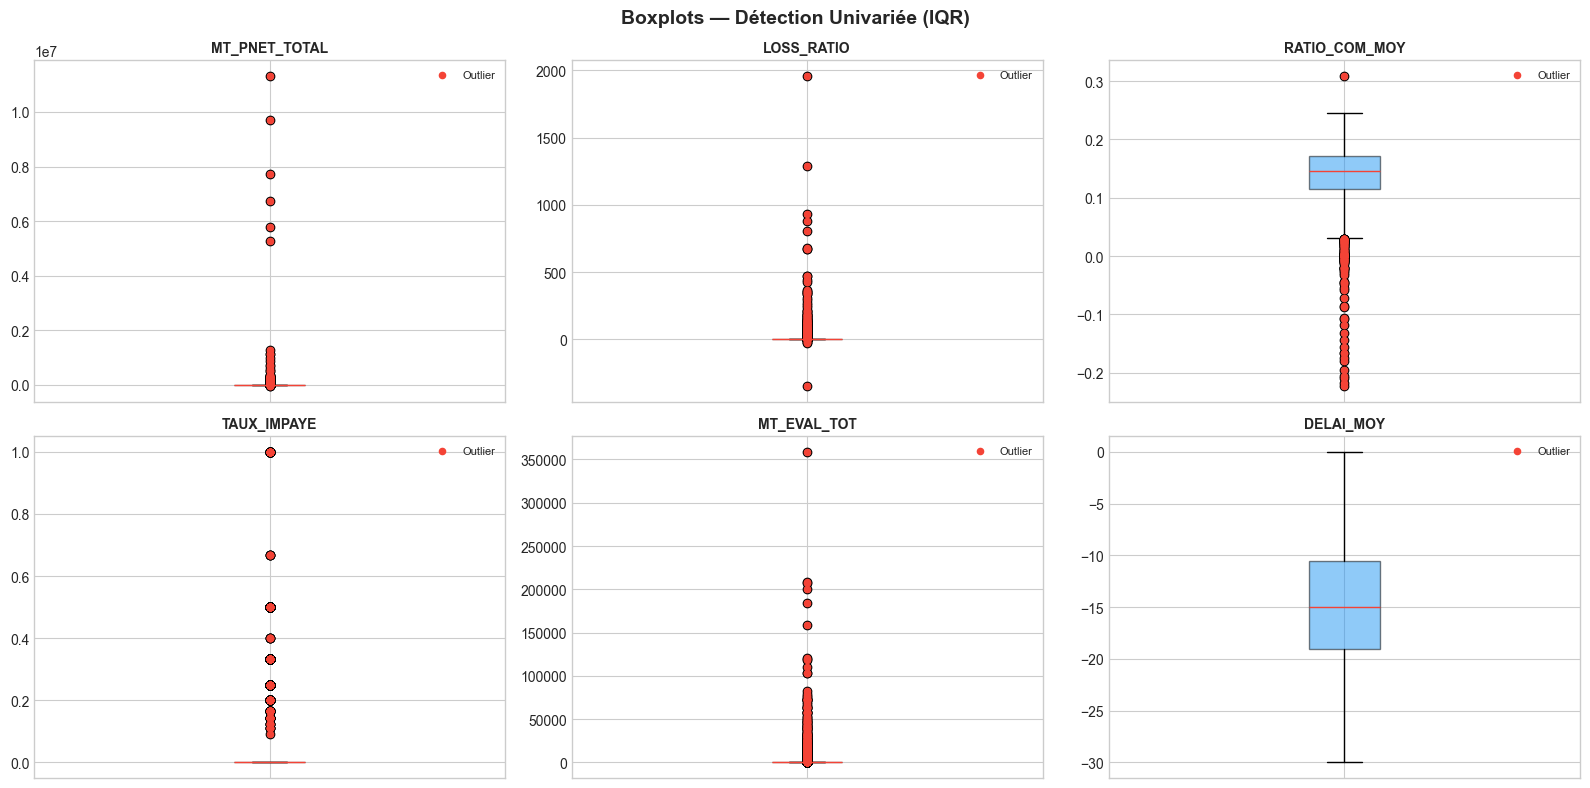

In [78]:
NUMERIC_COLS = ['MT_PNET_TOTAL', 'LOSS_RATIO', 'RATIO_COM_MOY',
               'TAUX_IMPAYE', 'MT_EVAL_TOT', 'DELAI_MOY']

results_zscore = {}
results_iqr    = {}

for col in NUMERIC_COLS:
    series = df_police[col].dropna()
    z      = np.abs(stats.zscore(series))
    q1, q3 = series.quantile([0.25, 0.75])
    iqr    = q3 - q1
    results_zscore[col] = int((z > 3).sum())
    results_iqr[col]    = int(((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum())

df_uni = pd.DataFrame({'Z-Score (|z|>3)': results_zscore,
                       'IQR (1.5×)':       results_iqr})
print("Anomalies univariées par feature :")
display(df_uni)

# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, (col, ax) in enumerate(zip(NUMERIC_COLS, axes.flatten())):
    vals = df_police[col]
    q1, q3 = vals.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = vals[(vals < lower) | (vals > upper)]
    normal   = vals[(vals >= lower) & (vals <= upper)]
    ax.boxplot(vals.dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=PALETTE[0], alpha=0.5))
    ax.scatter([1]*len(outliers), outliers, color=PALETTE[1], s=20, zorder=5, label='Outlier')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xticklabels([])
    ax.legend(fontsize=8)

plt.suptitle('Boxplots — Détection Univariée (IQR)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Score de Consensus Multi-Modèles

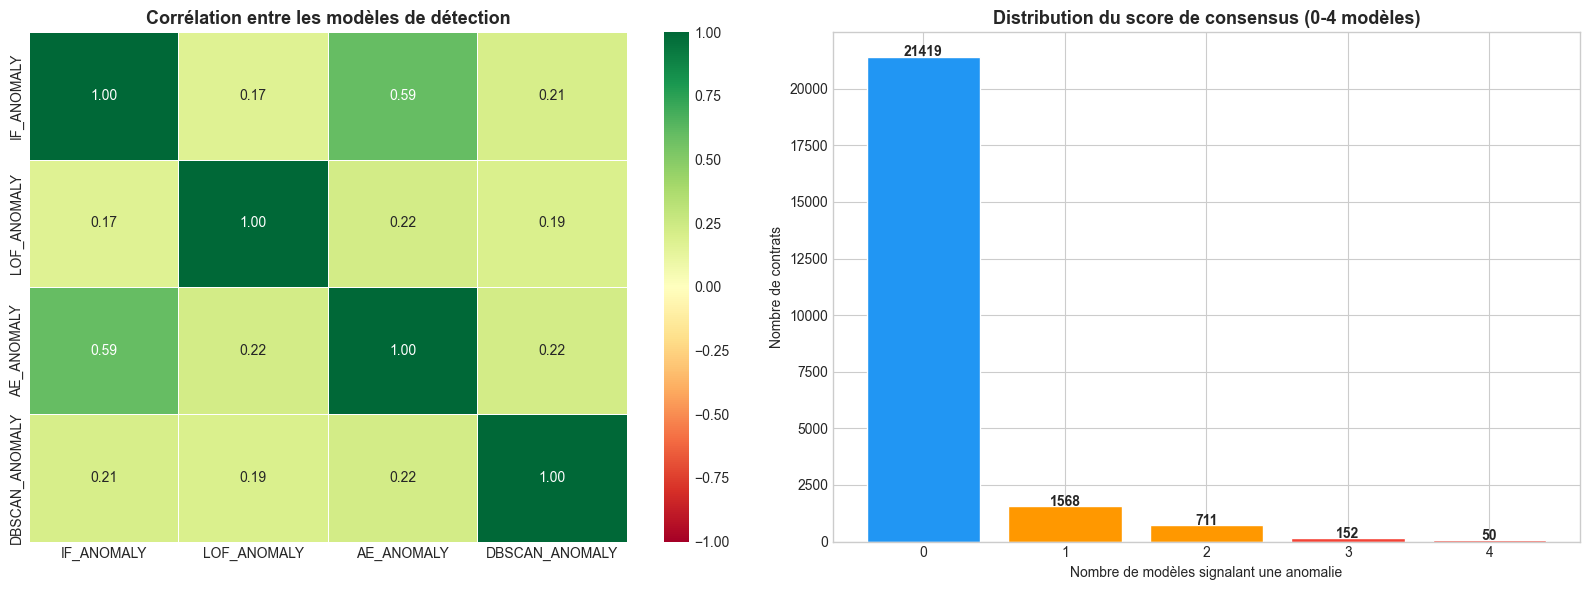


Répartition :
  Score 0 — ✅ Normal                       : 21419 contrats
  Score 1 — ⚠️ Suspect (1/4)               :  1568 contrats
  Score 2 — 🔶 Suspect (2/4)                :   711 contrats
  Score 3 — 🔴 Anomalie (3/4)               :   152 contrats
  Score 4 — 🚨 Anomalie confirmée (4/4)     :    50 contrats


In [79]:
df_police['ANOMALY_SCORE'] = (
    df_police['IF_ANOMALY']    +
    df_police['LOF_ANOMALY']   +
    df_police['AE_ANOMALY']    +
    df_police['DBSCAN_ANOMALY']
)

# Heatmap des accords
anom_cols = ['IF_ANOMALY', 'LOF_ANOMALY', 'AE_ANOMALY', 'DBSCAN_ANOMALY']
agreement = df_police[anom_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sns.heatmap(agreement, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Corrélation entre les modèles de détection', fontsize=13, fontweight='bold')

ax = axes[1]
score_counts = df_police['ANOMALY_SCORE'].value_counts().sort_index()
colors_bar = [PALETTE[0], PALETTE[3], PALETTE[3], PALETTE[1], PALETTE[1]]
ax.bar(score_counts.index.astype(str), score_counts.values,
       color=colors_bar[:len(score_counts)], edgecolor='white')
for i, (idx, val) in enumerate(score_counts.items()):
    ax.text(i, val + 5, str(val), ha='center', fontweight='bold')
ax.set_title('Distribution du score de consensus (0-4 modèles)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nombre de modèles signalant une anomalie')
ax.set_ylabel('Nombre de contrats')

plt.tight_layout()
plt.show()

print("\nRépartition :")
for score, count in score_counts.items():
    label = {0:'✅ Normal', 1:'⚠️ Suspect (1/4)',
             2:'🔶 Suspect (2/4)', 3:'🔴 Anomalie (3/4)',
             4:'🚨 Anomalie confirmée (4/4)'}.get(score, score)
    print(f"  Score {score} — {label:<30} : {count:>5} contrats")


## 12. Analyse des Top Anomalies

In [80]:
# Contrats les plus suspects
top_anomalies = df_police[df_police['ANOMALY_SCORE'] >= 3].copy()
top_anomalies = top_anomalies.sort_values(['ANOMALY_SCORE', 'IF_SCORE'])

print(f"Contrats avec score ≥ 3 : {len(top_anomalies)}")
print()

display(top_anomalies[[
    'ID_POLICE', 'BRANCHE', 'NB_QUITTANCES', 'MT_PNET_TOTAL',
    'LOSS_RATIO', 'TAUX_IMPAYE', 'NB_SINISTRES',
    'IF_SCORE', 'LOF_SCORE', 'AE_RECON_ERROR', 'ANOMALY_SCORE'
]].head(20).round(3))


Contrats avec score ≥ 3 : 202



,ID_POLICE,BRANCHE,NB_QUITTANCES,MT_PNET_TOTAL,LOSS_RATIO,TAUX_IMPAYE,NB_SINISTRES,IF_SCORE,LOF_SCORE,AE_RECON_ERROR,ANOMALY_SCORE
23160,29075,SANTE,3,161548.02,0.00,0.33,0.00,-0.70,1.73,4.22,3
23085,28976,SANTE,4,254444.35,0.00,0.25,1.00,-0.70,1.80,5.12,3
7417,9267,AUTO,3,74526.22,0.02,0.33,1.00,-0.69,1.37,2.96,3
5340,6673,AUTO,5,89965.80,0.00,0.40,0.00,-0.68,1.59,8.30,3
23618,29661,SANTE,1,56661.82,0.00,1.00,0.00,-0.68,2.83,1.58,3
23125,29030,SANTE,5,193870.20,0.00,0.20,2.00,-0.67,1.92,0.44,3
23762,29840,SANTE,3,123142.18,0.00,0.33,1.00,-0.66,1.38,2.49,3
23232,29165,SANTE,2,44618.40,0.01,0.50,3.00,-0.66,1.82,0.85,3
23858,29954,SANTE,9,301661.97,0.00,0.11,0.00,-0.66,2.24,0.81,3
4247,5309,AUTO,2,1142.55,25.28,0.50,3.00,-0.65,2.63,2.09,3


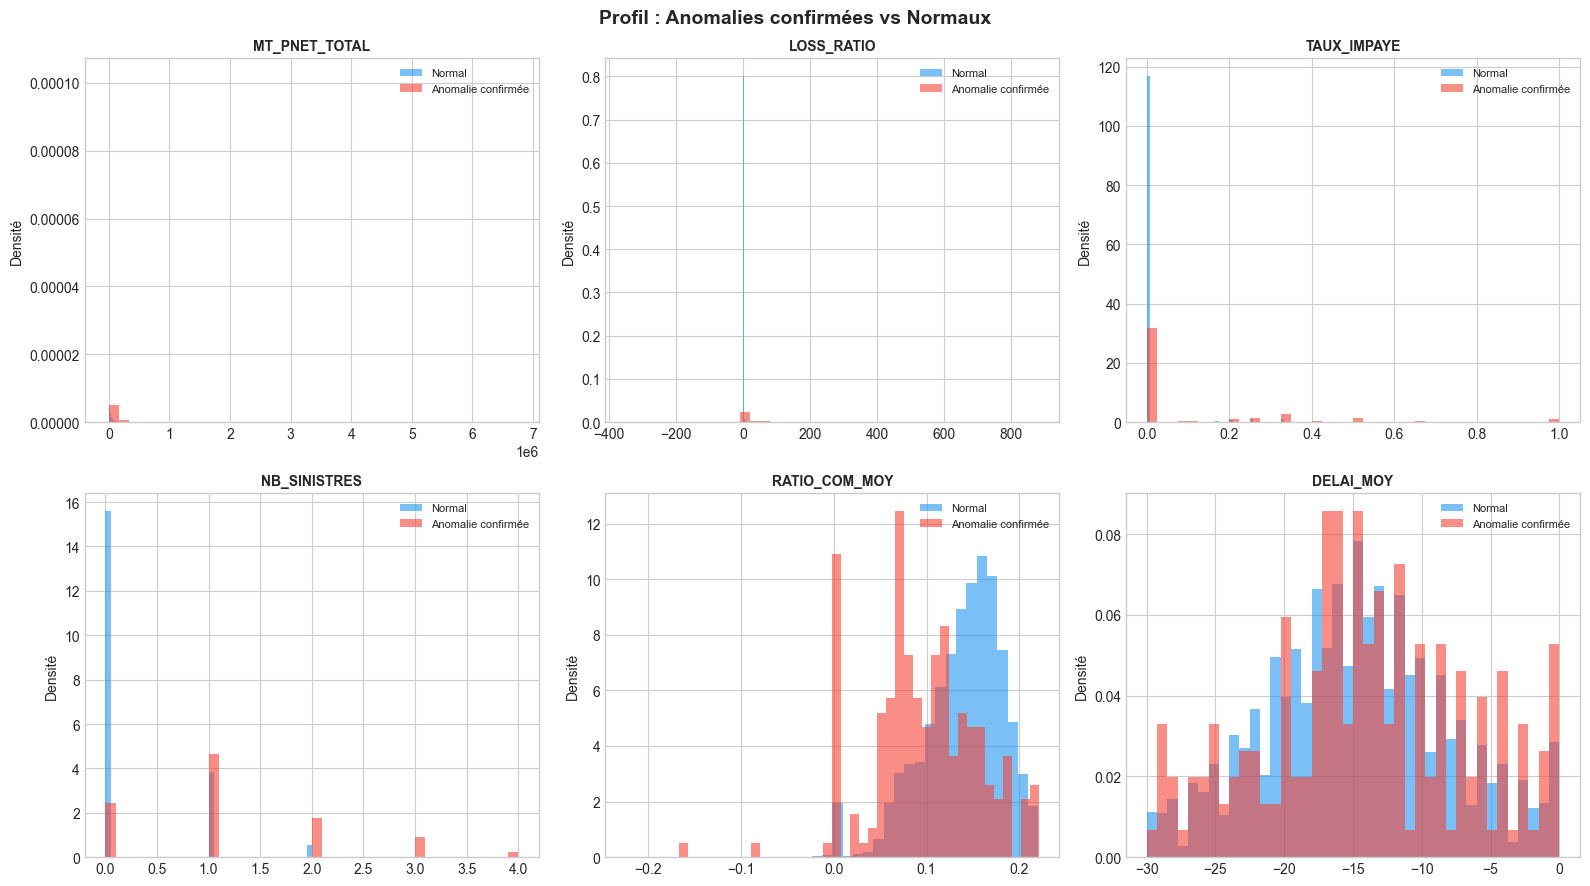

In [81]:
# Profil des anomalies vs normaux
df_compare = df_police.copy()
df_compare['GROUPE'] = df_compare['ANOMALY_SCORE'].apply(
    lambda s: 'Anomalie confirmée' if s >= 3 else 'Normal'
)

features_compare = ['MT_PNET_TOTAL', 'LOSS_RATIO', 'TAUX_IMPAYE',
                    'NB_SINISTRES', 'RATIO_COM_MOY', 'DELAI_MOY']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, ax in zip(features_compare, axes.flatten()):
    for grp, color in zip(['Normal', 'Anomalie confirmée'], [PALETTE[0], PALETTE[1]]):
        vals = df_compare.loc[df_compare['GROUPE'] == grp, col].dropna()
        q99 = vals.quantile(0.99)
        vals = vals[vals <= q99]
        ax.hist(vals, bins=40, alpha=0.6, color=color, label=grp, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Densité')

plt.suptitle('Profil : Anomalies confirmées vs Normaux', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 13. Importance des Features dans la Détection

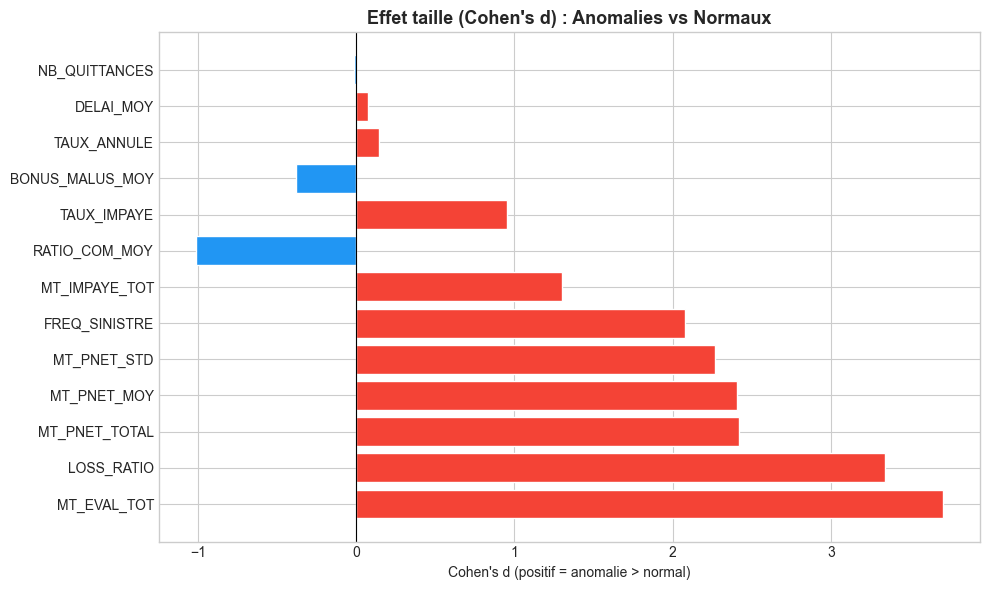

In [82]:
# Différence des moyennes normalisées (effet taille)
anom_mask   = df_police['ANOMALY_SCORE'] >= 3
normal_mask = df_police['ANOMALY_SCORE'] == 0

effects = {}
for col in FEATURES:
    mu_anom   = df_police.loc[anom_mask,   col].mean()
    mu_normal = df_police.loc[normal_mask, col].mean()
    std_pool  = df_police[col].std() + 1e-9
    effects[col] = (mu_anom - mu_normal) / std_pool   # Cohen's d simplifié

effects_df = pd.Series(effects).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = [PALETTE[1] if v > 0 else PALETTE[0] for v in effects_df]
ax.barh(effects_df.index, effects_df.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Effet taille (Cohen's d) : Anomalies vs Normaux", fontsize=13, fontweight='bold')
ax.set_xlabel("Cohen's d (positif = anomalie > normal)")
plt.tight_layout()
plt.show()


## 14. Export des Résultats

In [83]:
# Résumé final
print()
print("=" * 50)
print("  RÉSUMÉ FINAL — DÉTECTION D'ANOMALIES")
print("=" * 50)
print(f"  Total contrats analysés   : {len(df_police):>7,}")
print(f"  Anomalies IF              : {df_police['IF_ANOMALY'].sum():>7,}  ({df_police['IF_ANOMALY'].mean():.1%})")
print(f"  Anomalies LOF             : {df_police['LOF_ANOMALY'].sum():>7,}  ({df_police['LOF_ANOMALY'].mean():.1%})")
print(f"  Anomalies Autoencoder     : {df_police['AE_ANOMALY'].sum():>7,}  ({df_police['AE_ANOMALY'].mean():.1%})")
print(f"  Anomalies DBSCAN          : {df_police['DBSCAN_ANOMALY'].sum():>7,}  ({df_police['DBSCAN_ANOMALY'].mean():.1%})")
print(f"  Score ≥ 3 (haute priorité): {(df_police['ANOMALY_SCORE']>=3).sum():>7,}  ({(df_police['ANOMALY_SCORE']>=3).mean():.1%})")
print("=" * 50)



  RÉSUMÉ FINAL — DÉTECTION D'ANOMALIES
  Total contrats analysés   :  23,900
  Anomalies IF              :   1,195  (5.0%)
  Anomalies LOF             :   1,195  (5.0%)
  Anomalies Autoencoder     :   1,195  (5.0%)
  Anomalies DBSCAN          :      61  (0.3%)
  Score ≥ 3 (haute priorité):     202  (0.8%)
